In [2]:
import pandas as pd
df = pd.read_csv("athlete_data.csv")
df.isnull().sum()

,0
ID,0
Name,0
Sex,0
Age,9474
Height,60171
Weight,62875
Team,0
NOC,0
Games,0
Year,0


In [3]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Height"] = df["Height"].fillna(df["Height"].median())
df["Weight"] = df["Weight"].fillna(df["Weight"].median())
df["Medal"] = df["Medal"].fillna("Didn't Win")

In [4]:
print(df["Age"].median())
print(df["Height"].median())
print(df["Weight"].median())

24.0
175.0
70.0


In [5]:
print(df[["Age", "Height", "Weight","Medal"]].describe())

                 Age        Height         Weight
count  271116.000000  271116.00000  271116.000000
mean       25.502493     175.26374      70.539500
std         6.287361       9.27917      12.578184
min        10.000000     127.00000      25.000000
25%        22.000000     170.00000      63.000000
50%        24.000000     175.00000      70.000000
75%        28.000000     180.00000      75.000000
max        97.000000     226.00000     214.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     271116 non-null  float64
 4   Height  271116 non-null  float64
 5   Weight  271116 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   271116 non-null  object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [7]:
df.shape

(271116, 15)

In [8]:
import numpy as np

df.replace("NA", np.nan, inplace=True)

In [9]:
print(df[["Age", "Height", "Weight","Medal"]].isnull().sum())

Age       0
Height    0
Weight    0
Medal     0
dtype: int64


In [10]:
df.drop("ID", axis=1, inplace=True)


In [11]:
print(df.columns)

Index(['Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')


In [12]:
df.to_csv("athlete_events_cleaned.csv", index=False)

 ANALYSIS

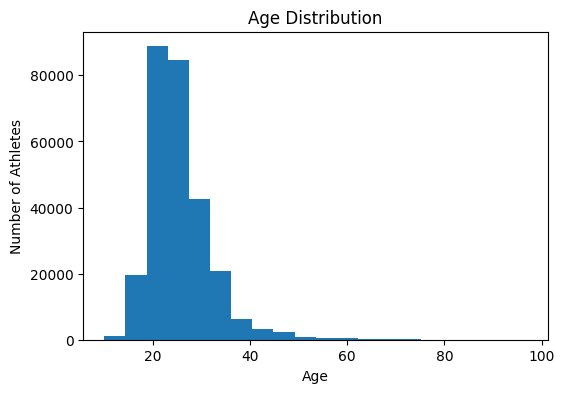

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Athletes")
plt.show()

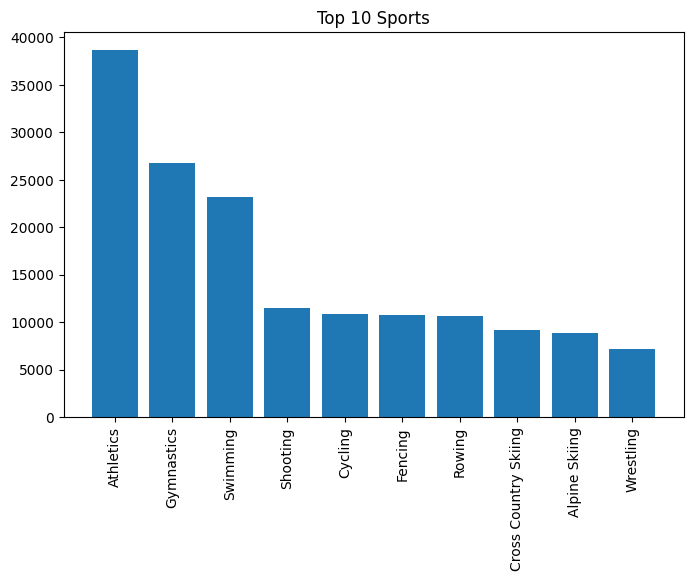

In [14]:
top_sports = df["Sport"].value_counts().head(10)

plt.figure(figsize=(8,5))
plt.bar(top_sports.index, top_sports.values)

plt.xticks(rotation=90)
plt.title("Top 10 Sports")
plt.show()

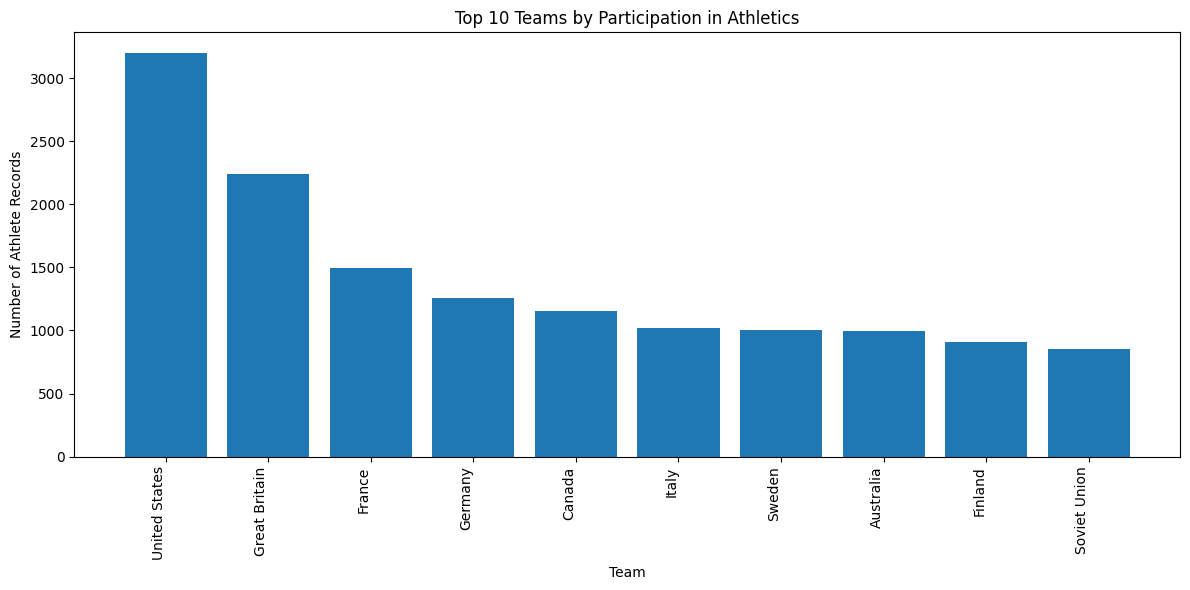

In [15]:
import matplotlib.pyplot as plt

athletics = df[df["Sport"] == "Athletics"]
top_teams = athletics["Team"].value_counts().head(10)

plt.figure(figsize=(12,6))
plt.bar(top_teams.index, top_teams.values)

plt.title("Top 10 Teams by Participation in Athletics")
plt.xlabel("Team")
plt.ylabel("Number of Athlete Records")

plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

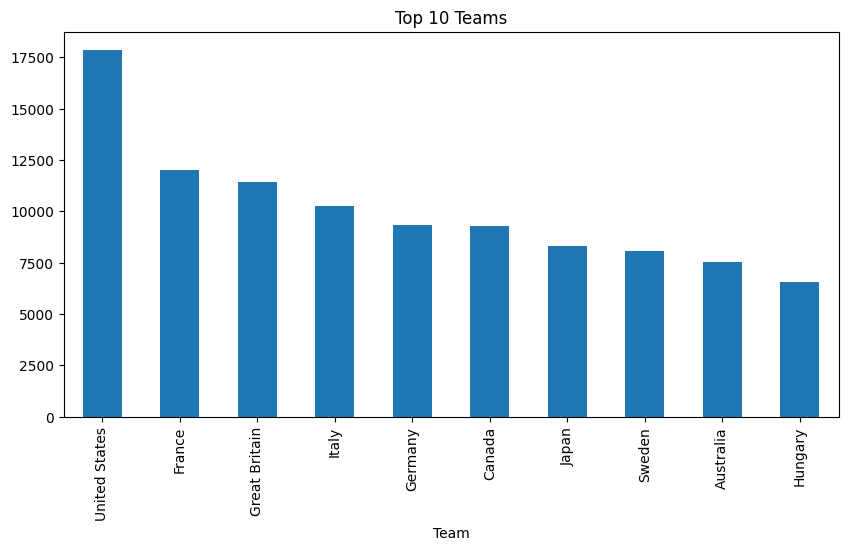

In [16]:
df["Team"].value_counts().head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Teams")
plt.show()

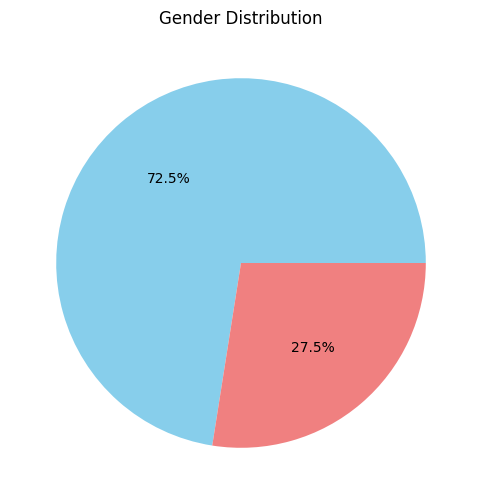

In [17]:
gender = df["Sex"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    gender,
    autopct="%1.1f%%",
    colors=["skyblue", "lightcoral"]
)

plt.title("Gender Distribution")
plt.show()

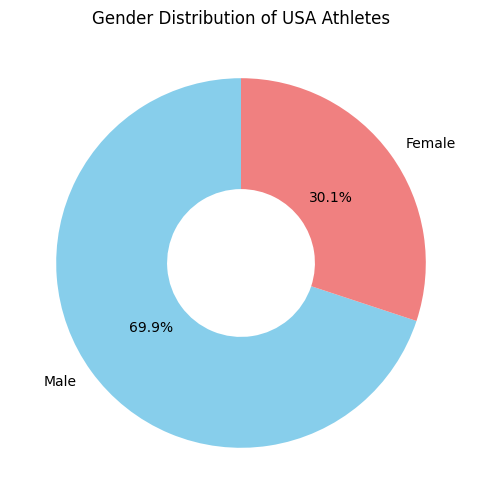

In [18]:
plt.figure(figsize=(6,6))
usa = df[df["Team"] == "United States"]
gender_counts = usa["Sex"].value_counts()
gender_counts.index = ["Male", "Female"]
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    colors=["skyblue", "lightcoral"],
    startangle=90,
    wedgeprops=dict(width=0.6)
)

plt.title("Gender Distribution of USA Athletes")

plt.show()

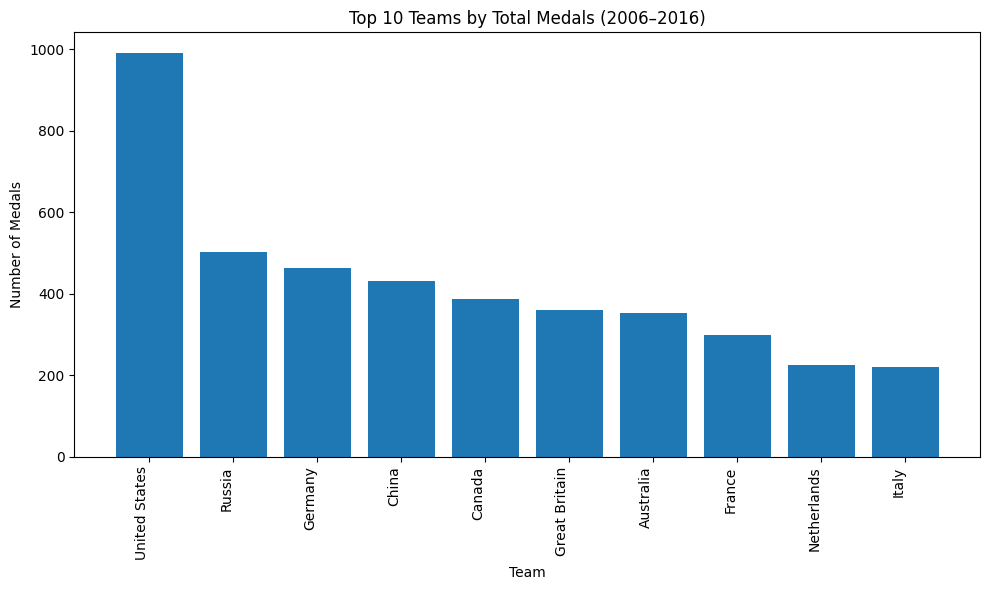

In [19]:
import matplotlib.pyplot as plt

last_10_years = df[df["Year"] >= 2006]


medal_winners = last_10_years[
    last_10_years["Medal"].isin(["Gold", "Silver", "Bronze"])
]

top_teams = medal_winners["Team"].value_counts().head(10)

plt.figure(figsize=(10,6))

plt.bar(top_teams.index, top_teams.values, )

plt.title("Top 10 Teams by Total Medals (2006–2016)")
plt.xlabel("Team")
plt.ylabel("Number of Medals")

plt.xticks(rotation=90, ha="right")
plt.tight_layout()

plt.show()

In [20]:
medal_map = {
    "Didn't Win": 0,
    "Bronze": 1,
    "Silver": 2,
    "Gold": 3
}

df["Medal_Num"] = df["Medal"].map(medal_map)

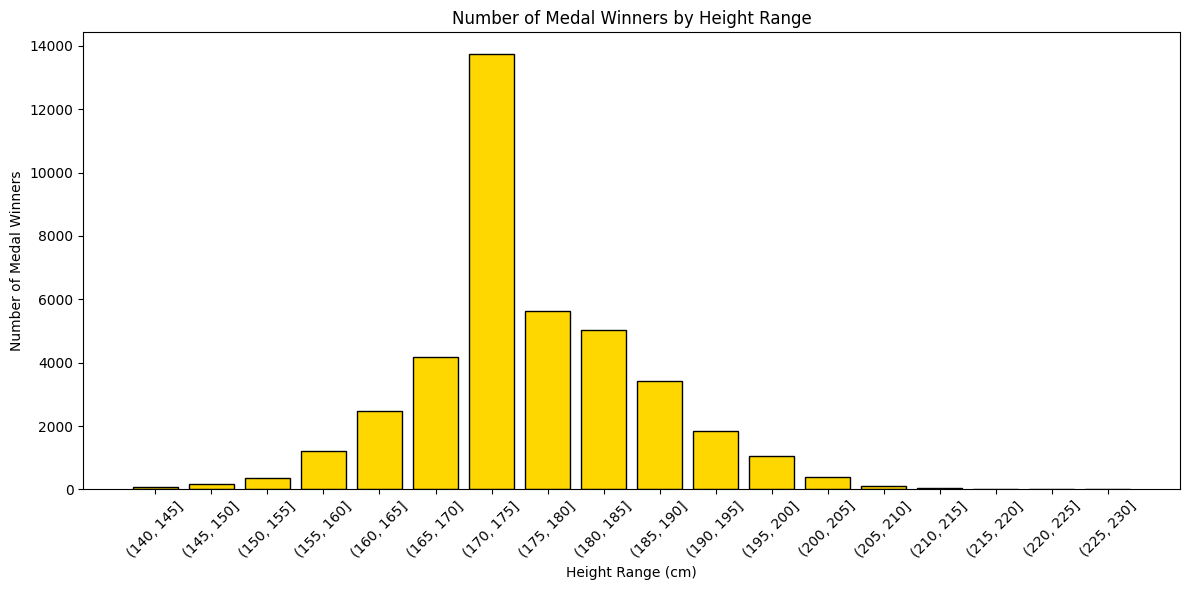

In [21]:
medals = df[df["Medal"].isin(["Gold", "Silver", "Bronze"])].copy()

bins = range(140, 231, 5)
medals["Height Range"] = pd.cut(medals["Height"], bins=bins)

height_counts = medals["Height Range"].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.bar(
    height_counts.index.astype(str),
    height_counts.values,
    color="gold",
    edgecolor="black"
)

plt.title("Number of Medal Winners by Height Range")
plt.xlabel("Height Range (cm)")
plt.ylabel("Number of Medal Winners")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

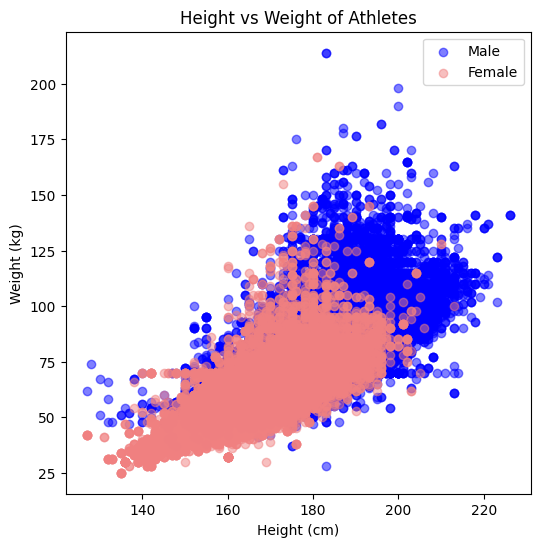

In [22]:

male = df[df["Sex"] == "M"]
female = df[df["Sex"] == "F"]

plt.figure(figsize=(6, 6))

plt.scatter(
    male["Height"],
    male["Weight"],
    alpha=0.5,
    color="blue",
    label="Male"
)
plt.scatter(
    female["Height"],
    female["Weight"],
    alpha=0.5,
    color="lightcoral",
    label="Female"
)

plt.title("Height vs Weight of Athletes")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.legend()
plt.show()

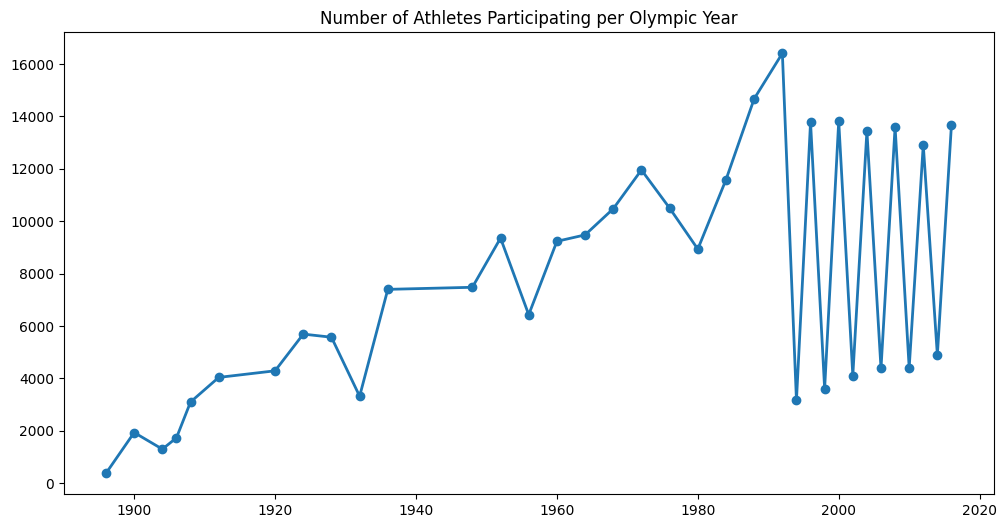

In [25]:
import matplotlib.pyplot as plt
athletes_per_year = df["Year"].value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.plot(
    athletes_per_year.index,
    athletes_per_year.values,
    marker='o',
    linewidth=2
)

plt.title("Number of Athletes Participating per Olympic Year")
plt.show()

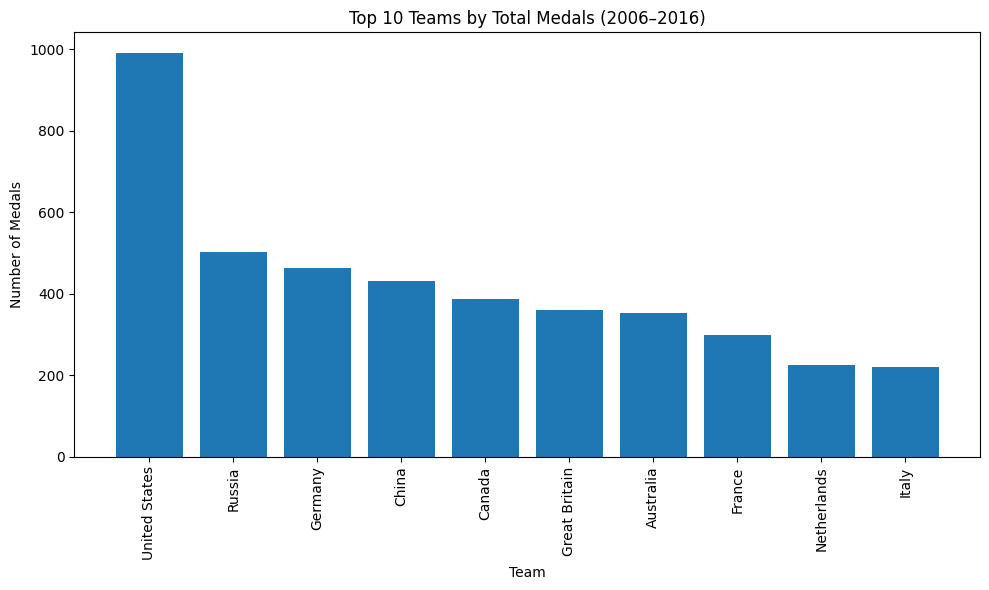

In [32]:
import matplotlib.pyplot as plt

last_10_years = df[(df["Year"] >= 2006) & (df["Year"] <= 2016)]
medal_winners = last_10_years[
    last_10_years["Medal"].isin(["Gold", "Silver", "Bronze"])
]
top_teams = medal_winners["Team"].value_counts().head(10)
plt.figure(figsize=(10,6))
plt.bar(top_teams.index, top_teams.values)

plt.title("Top 10 Teams by Total Medals (2006–2016)")
plt.xlabel("Team")
plt.ylabel("Number of Medals")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

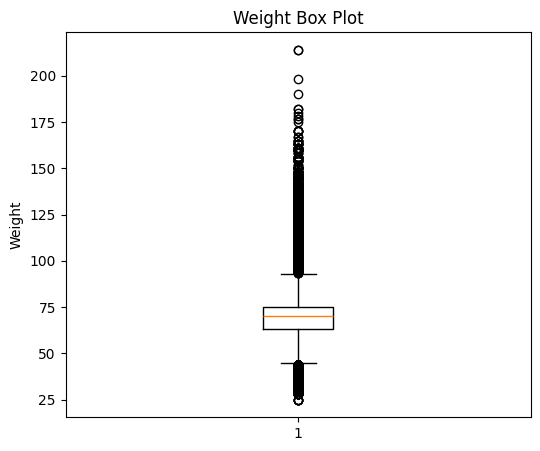

In [33]:
plt.figure(figsize=(6,5))
plt.boxplot(df["Weight"].dropna())
plt.title("Weight Box Plot")
plt.ylabel("Weight")
plt.show()

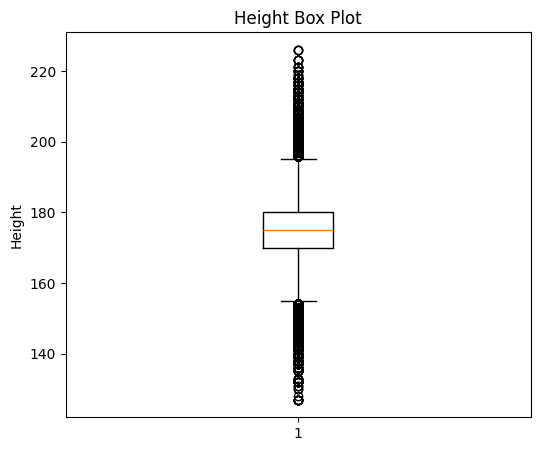

In [30]:
plt.figure(figsize=(6,5))
plt.boxplot(df["Height"].dropna())
plt.title("Height Box Plot")
plt.ylabel("Height")
plt.show()

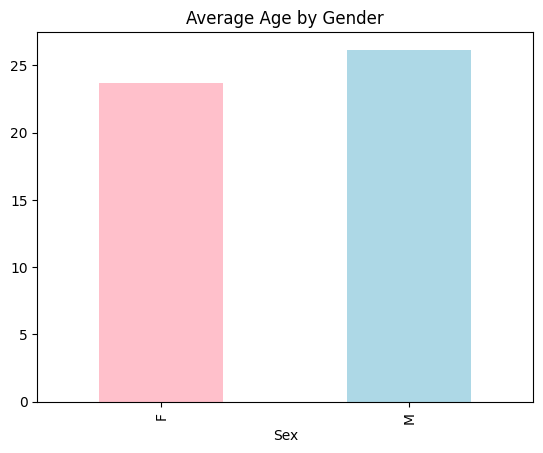

In [34]:
avg_age = df.groupby('Sex')['Age'].mean()

avg_age.plot(kind='bar', color=['pink','lightblue'])

plt.title('Average Age by Gender')
plt.show()

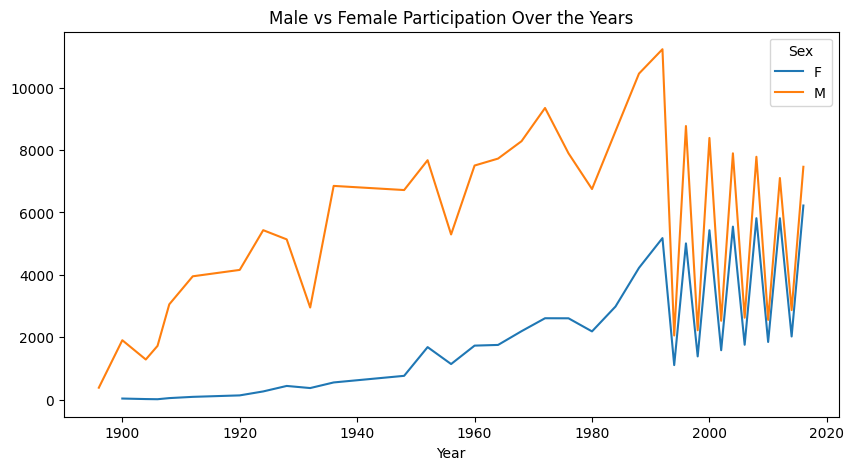

In [35]:
gender_year = df.groupby(['Year', 'Sex']).size().unstack()

gender_year.plot(figsize=(10,5))

plt.title('Male vs Female Participation Over the Years')
plt.show()

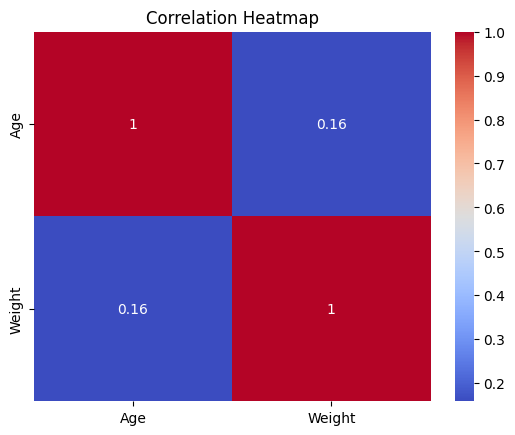

In [36]:
import seaborn as sns
corr = df[['Age', 'Weight']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

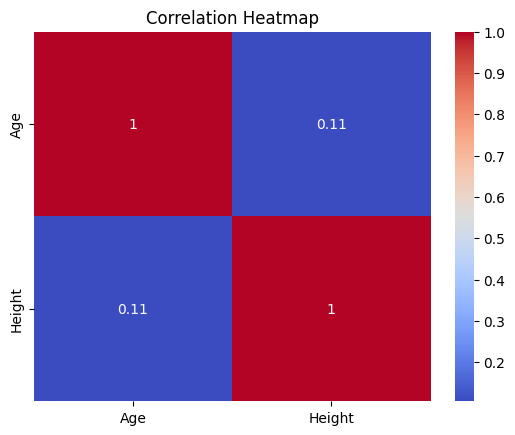

In [37]:
import seaborn as sns
corr = df[['Age', 'Height']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# **TESTING**

In [42]:
from scipy.stats import ttest_ind

male = df[df['Sex'] == 'M']['Height'].dropna()
female = df[df['Sex'] == 'F']['Height'].dropna()

t_stat, p_value = ttest_ind(male, female)

print("T-statistic:", t_stat)
print("P-value:", p_value)

print("This output means there is a very significant difference in average Height between male and female \nathletes.")
print("We reject the null hypothesis. \nThe null hypothesis was: Male and female athletes have the same average height.")

T-statistic: 260.22179999482717
P-value: 0.0
This output means there is a very significant difference in average Height between male and female 
athletes.
We reject the null hypothesis. 
The null hypothesis was: Male and female athletes have the same average height.


# **INSIGHTS**

Insight 1: Age Distribution
Most athletes are between 20 and 30 years old.
Very young and older athletes are less common, indicating that peak athletic performance is generally achieved in early adulthood.

Insight 2: Gender Distribution
Male athletes outnumber female athletes in the dataset.However, female participation has increased over the years, showing improved gender inclusion in sports.

Insight 3: Most Popular Sports
Sports such as Athletics, Swimming, Football, and Gymnastics have the highest number of participants.
These sports attract athletes from many countries and have numerous events.

Insight 4: Height vs Weight
There is a positive relationship between height and weight. Taller athletes generally tend to weigh more, although the relationship is not perfectly linear.

Insight 5: Athlete Participation Over the Years
The number of participating athletes has generally increased over time.
This reflects the growing popularity and global reach of the Olympic Games.

Insight 6: Height and Weight Box Plots
Both height and weight contain several outliers.
This justifies using the median to fill missing values instead of the mean.

Insight 7: Correlation Heatmap
Height and weight have the strongest positive correlation.
Age has only a weak relationship with height and weight.

# **Conclusion**

The analysis shows that Olympic athletes are predominantly young adults, with participation increasing steadily over time. Athletics and swimming are among the most popular sports, while height and weight exhibit a strong positive relationship. The presence of outliers in physical measurements supports the use of median imputation during data preprocessing. Overall, the dataset provides valuable insights into athlete demographics, physical characteristics, and participation trends across Olympic history.

# **Recommendations**

1) Increase investment in women's sports to continue improving gender balance and participation.

2) Monitor participation trends regularly to assist in planning future Olympic events and resource allocation.

3) Use physical characteristics such as height and weight, alongside performance data, to support sport-specific training programs.